# 01 — Exploratory Data Analysis: Bank Customer Churn

**Goal:** understand who churns (`Exited = 1`) before building any model.
All plotting / statistics logic lives in `src/eda.py`; this notebook only calls those
functions and records observations. Every figure is also saved to `reports/figures/` (dpi = 150).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # make `src` importable from notebooks/

import pandas as pd
from IPython.display import display

from src import eda
from src.data import load_raw, validate

%matplotlib inline
pd.set_option("display.float_format", "{:,.3f}".format)

## Part A — Loading & validation

In [2]:
df = load_raw()
summary = validate(df)
summary

{'shape': (10000, 14),
 'null_counts': {'RowNumber': 0,
  'CustomerId': 0,
  'Surname': 0,
  'CreditScore': 0,
  'Geography': 0,
  'Gender': 0,
  'Age': 0,
  'Tenure': 0,
  'Balance': 0,
  'NumOfProducts': 0,
  'HasCrCard': 0,
  'IsActiveMember': 0,
  'EstimatedSalary': 0,
  'Exited': 0},
 'duplicate_rows': 0,
 'class_counts': {0: 7963, 1: 2037},
 'churn_rate': 0.2037}

**Observation:** the file passes every schema, dtype, range and target check — 10,000 rows × 14 columns,
no nulls, no duplicate rows. Class balance is 7,963 retained vs 2,037 churned (**20.4%**), i.e. ~4:1 imbalance.

## Part B — Univariate analysis
### Feature summary table

In [3]:
eda.summary_table(df)

,dtype,n_unique,min,max,mean,median,std,skewness,kurtosis
feature,,,,,,,,,
CreditScore,int64,460,350.000,850.000,650.529,652.000,96.653,-0.072,-0.426
Geography,str,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,str,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,int64,70,18.000,92.000,38.922,37.000,10.488,1.011,1.395
Tenure,int64,11,0.000,10.000,5.013,5.000,2.892,0.011,-1.165
Balance,float64,6382,0.000,"250,898.090","76,485.889","97,198.540","62,397.405",-0.141,-1.489
NumOfProducts,int64,4,1.000,4.000,1.530,1.000,0.582,0.746,0.583
HasCrCard,int64,2,0.000,1.000,0.706,1.000,0.456,-0.902,-1.187
IsActiveMember,int64,2,0.000,1.000,0.515,1.000,0.500,-0.060,-1.997


**Observation:** `Age` is the only clearly skewed feature (skew 1.01, kurtosis 1.40 — long right tail).
`Balance` has median 97,199 but mean 76,486: the gap is caused by the large block of zero balances.
`EstimatedSalary` is almost perfectly uniform (skew 0.00, kurtosis −1.18), which is unusual for real salaries.

### Target distribution

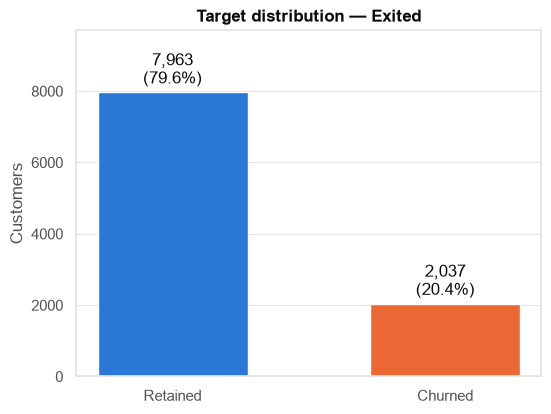

In [4]:
eda.plot_target_distribution(df);

**Observation:** 79.6% retained vs 20.4% churned. A model that always predicts "stays" already scores 79.6% accuracy,
so accuracy is a misleading metric here — we will optimise Recall on class 1 and PR-AUC.

### Continuous features — histogram + KDE and boxplot

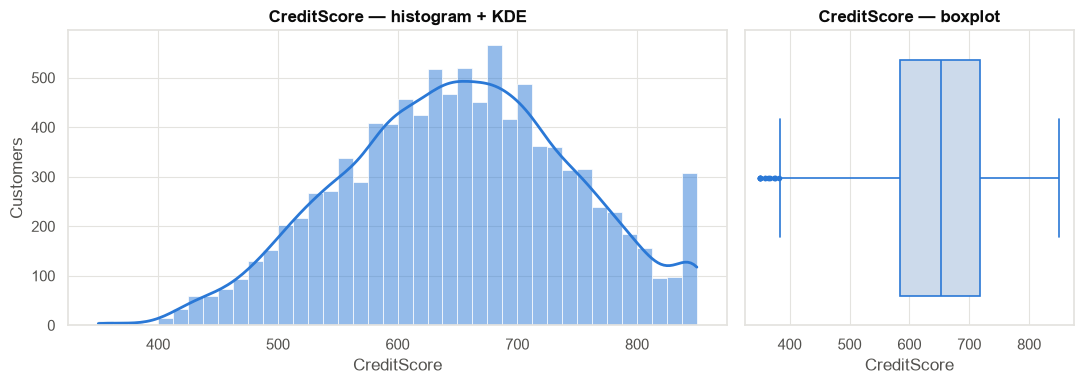

In [5]:
eda.plot_continuous_distribution(df, "CreditScore");

**Observation:** CreditScore is roughly bell-shaped around 650 (range 350–850) with a small pile-up at the 850 cap.
Only 15 low-side IQR outliers below 383 (0.15%).

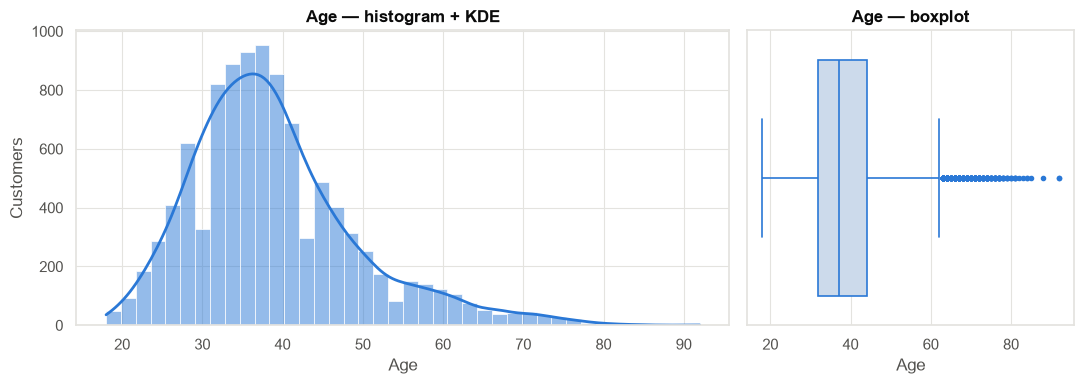

In [6]:
eda.plot_continuous_distribution(df, "Age");

**Observation:** Age is right-skewed (median 37, max 92). The boxplot flags 359 customers above 62 as outliers (3.6%) —
these are real, plausible older customers, not data errors.

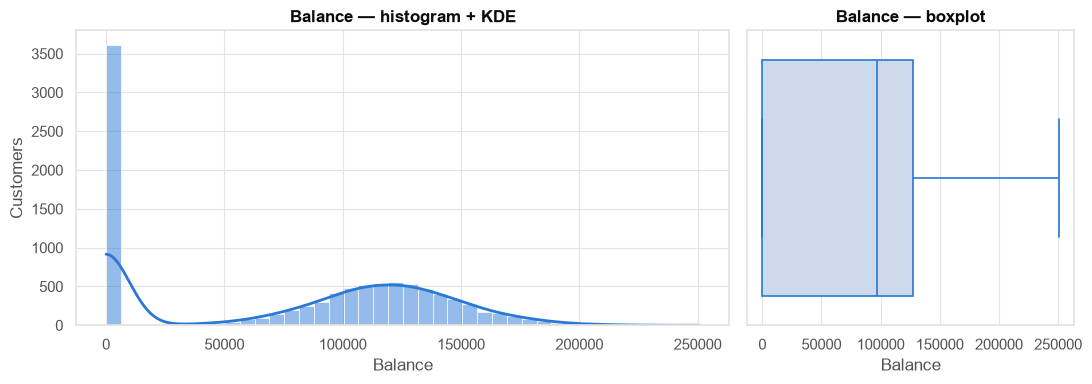

In [7]:
eda.plot_continuous_distribution(df, "Balance");

**Observation:** Balance is bimodal: a spike of 3,617 customers (36.2%) at exactly 0, then a near-normal hump centred
around 120k. The zero group behaves like a separate population and deserves its own flag.

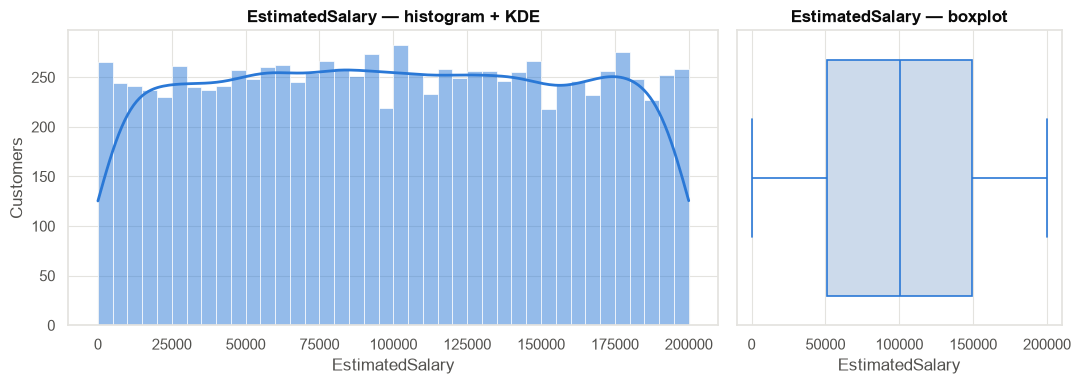

In [8]:
eda.plot_continuous_distribution(df, "EstimatedSalary");

**Observation:** EstimatedSalary is flat (uniform) between ~0 and 200k with no outliers — it looks synthetically
generated and is unlikely to carry much signal on its own.

### Categorical & discrete features — counts

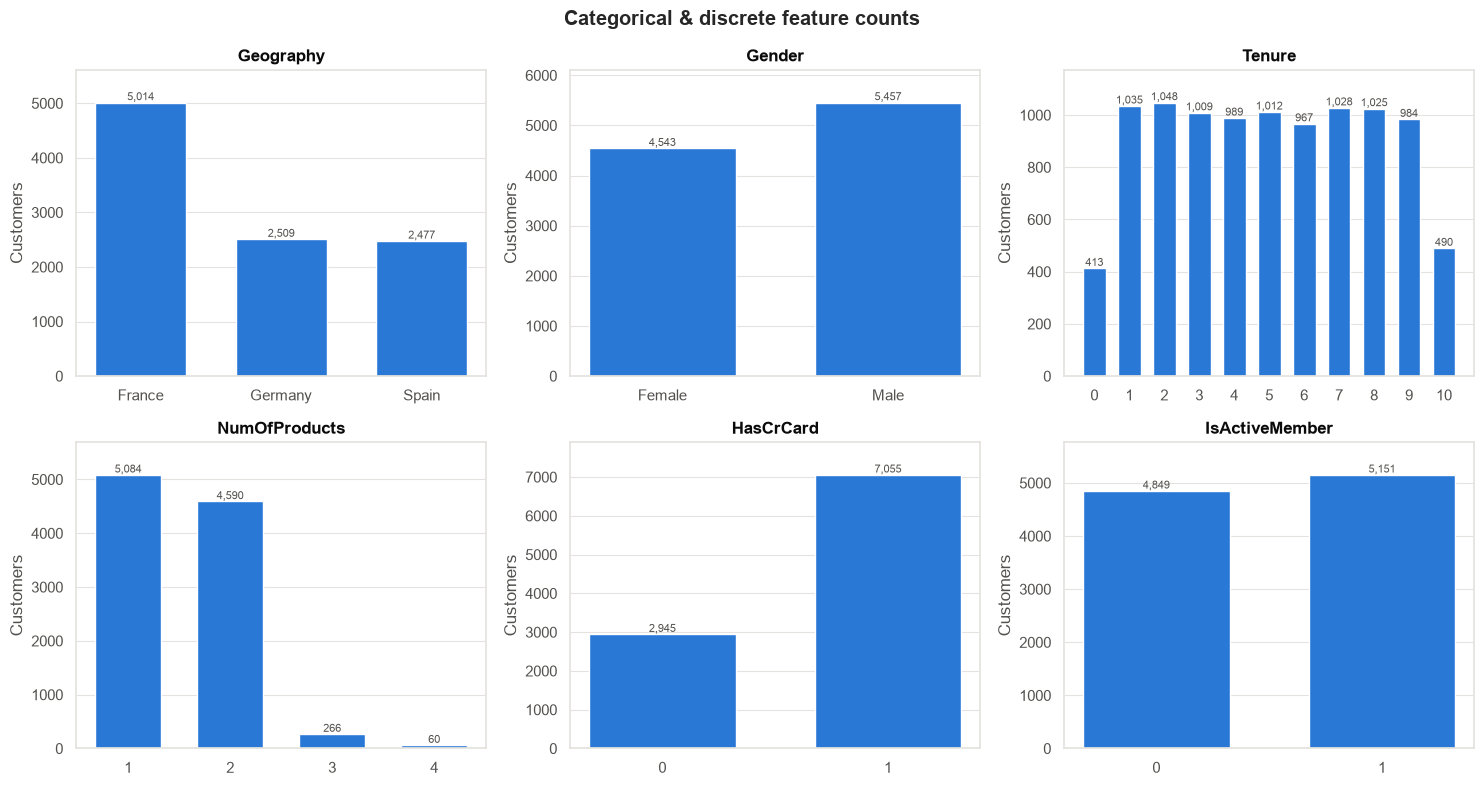

In [9]:
eda.plot_categorical_counts(df);

**Observation:** France holds half the customers (5,014); Germany and Spain ~2,500 each. 96.7% of customers have
1 or 2 products — 3 products (266) and 4 products (60) are rare, so their churn rates rest on small samples.
Tenure is close to uniform for 1–9 years; 0 and 10 years are about half as common.

### Outlier report (IQR rule — report only)

In [10]:
eda.outlier_report(df)

,q1,q3,iqr,lower_fence,upper_fence,n_below,n_above,n_outliers,pct_outliers
feature,,,,,,,,,
CreditScore,584.000,718.000,134.000,383.000,919.000,15,0,15,0.150
Age,32.000,44.000,12.000,14.000,62.000,0,359,359,3.590
Balance,0.000,"127,644.240","127,644.240","-191,466.360","319,110.600",0,0,0,0.000
EstimatedSalary,"51,002.110","149,388.250","98,386.140","-96,577.100","296,967.450",0,0,0,0.000


**Observation:** only Age (359, 3.6%) and CreditScore (15, 0.15%) have IQR outliers; Balance and EstimatedSalary have none.
**Decision:** keep all rows. The outliers are plausible values (ages 63–92, scores 350–382) and older customers are exactly
the high-churn group — deleting them would remove signal. We rely on robust/tree models instead.

## Part C — Bivariate analysis (feature vs churn)
### Churn rate by categorical feature

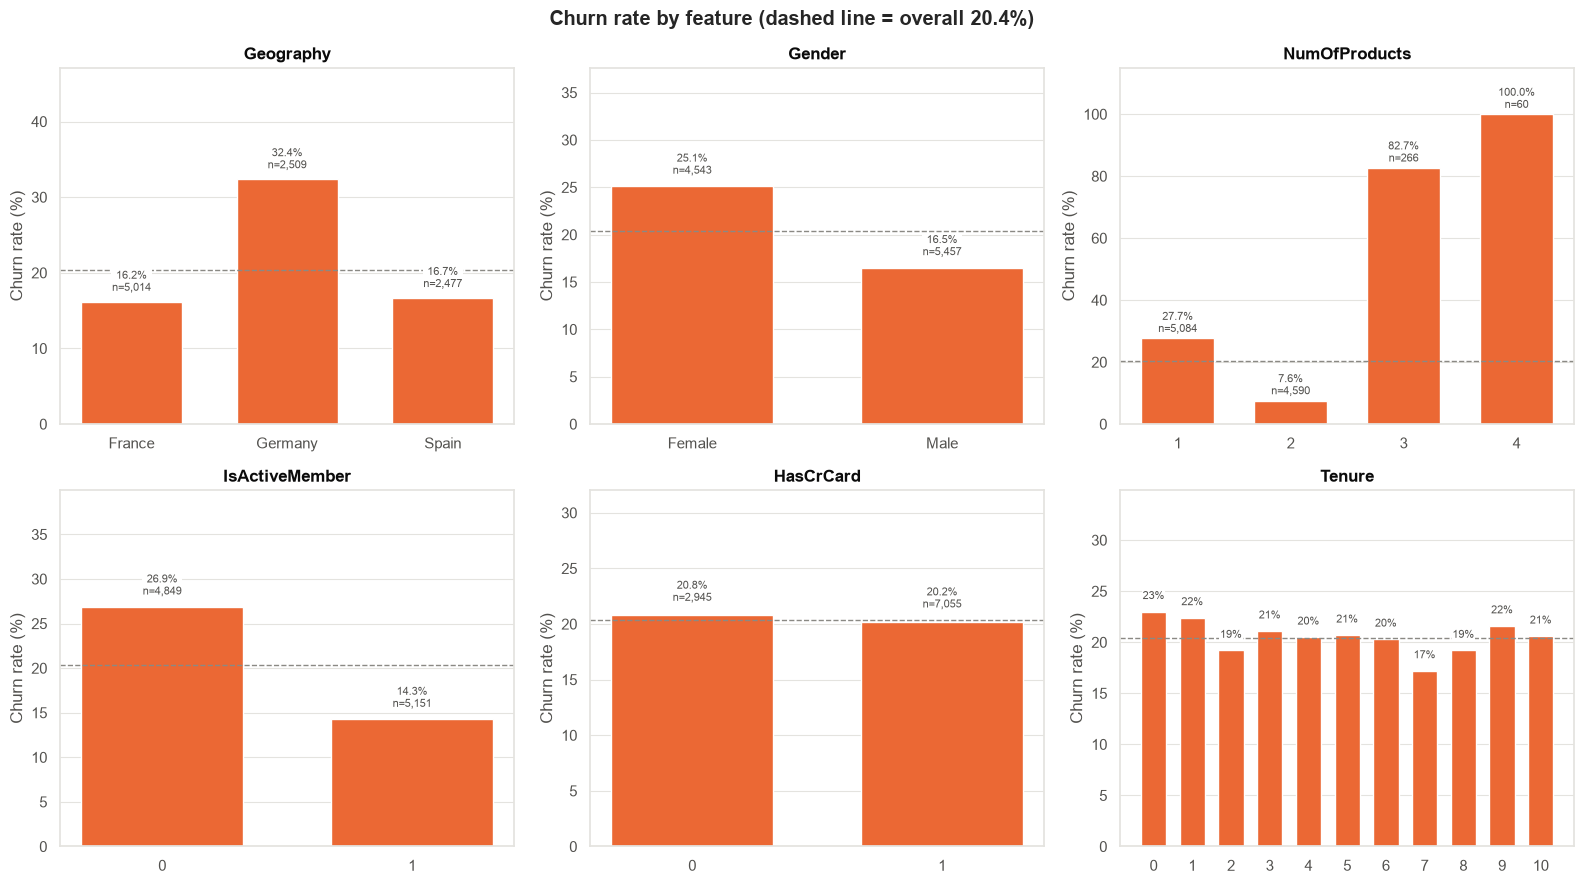

In [11]:
eda.plot_churn_rate_by_category(df);

**Observation:** Germany churns at **32.4%** vs 16.2% France / 16.7% Spain; women 25.1% vs men 16.5%; inactive members
26.9% vs active 14.3%. NumOfProducts is strongly non-linear: 27.7% (1) → **7.6% (2)** → 82.7% (3) → 100% (4).
HasCrCard (20.8% vs 20.2%) and Tenure (17–23%) barely move from the 20.4% baseline.

### Continuous features split by churn

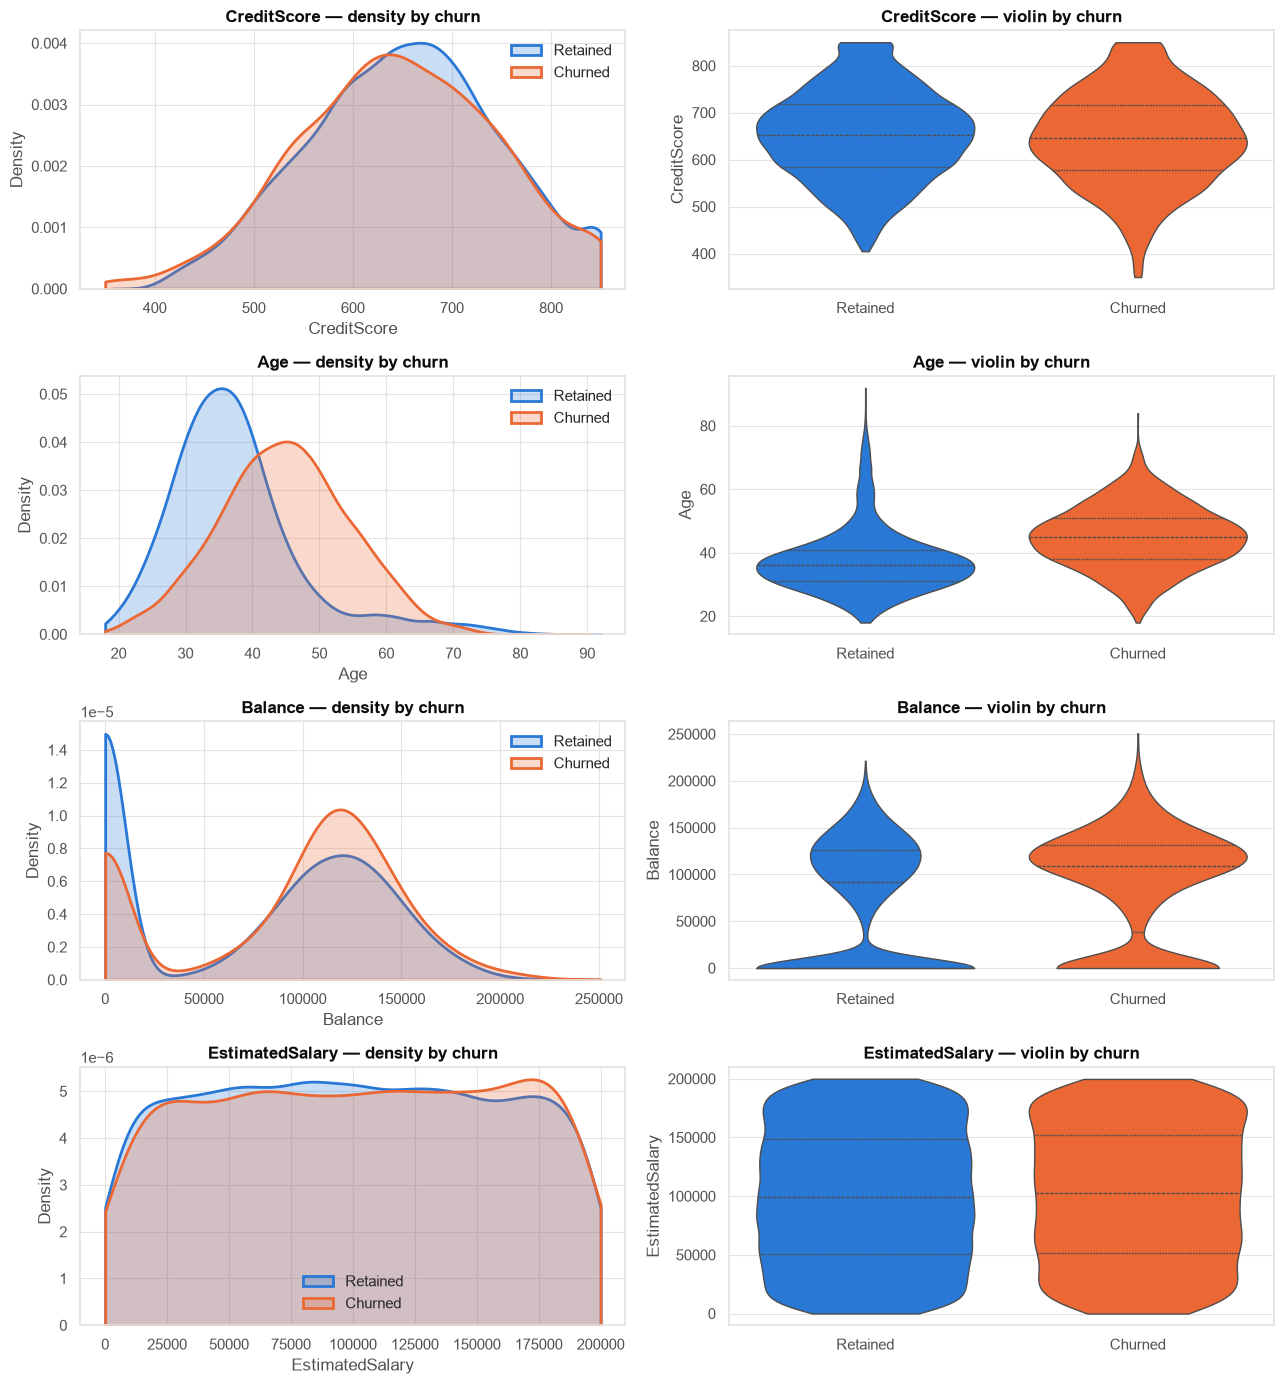

In [12]:
eda.plot_continuous_vs_churn(df);

**Observation:** Age separates the classes most clearly — median 45 for churners vs 36 for retained. Churners hold
higher balances (median 109k vs 92k) and are under-represented in the zero-balance spike. CreditScore and EstimatedSalary
distributions almost overlap.

### Churn rate by age band

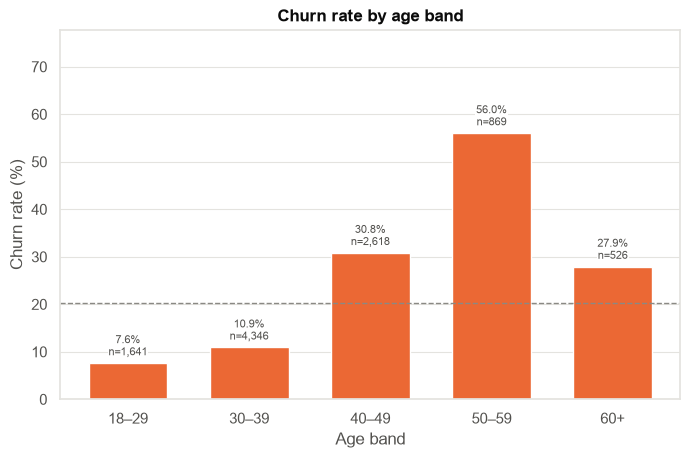

In [13]:
eda.plot_age_band_churn(df);

**Observation:** churn climbs steeply with age — 7.6% (18–29) → 10.9% (30–39) → 30.8% (40–49) → **56.0% (50–59)** —
then falls to 27.9% for 60+. The relationship is non-monotonic, so age bands / tree models should capture it better than a linear term.

### Churn rate: zero vs non-zero balance

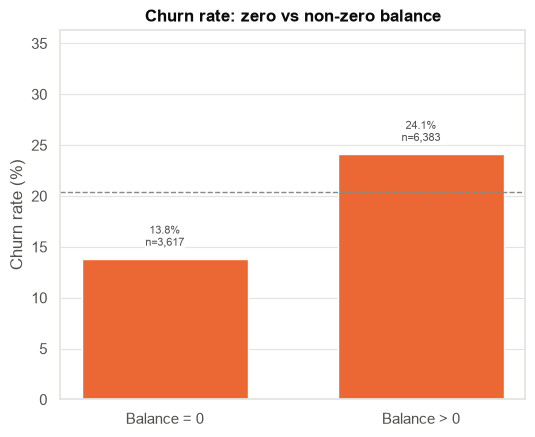

In [14]:
eda.plot_balance_zero_churn(df);

**Observation:** counter-intuitively, zero-balance customers churn *less* (13.8%) than customers with money in the
account (24.1%). Part of this is a Geography effect: **no** German customer has a zero balance, versus 48% elsewhere.

### Statistical tests (α = 0.05)

In [15]:
eda.statistical_tests(df)

,feature,test,statistic,dof,p_value,effect_size,effect_measure,significant
0,NumOfProducts,chi-square,"1,503.629",3.000,0.000,0.388,Cramer's V,yes
1,Age,Mann-Whitney U,"11,874,649.500",NaN,0.000,0.464,rank-biserial r,yes
2,Geography,chi-square,301.255,2.000,0.000,0.174,Cramer's V,yes
3,IsActiveMember,chi-square,242.985,1.000,0.000,0.156,Cramer's V,yes
4,Balance,Mann-Whitney U,"9,371,186.500",NaN,0.000,0.155,rank-biserial r,yes
5,Gender,chi-square,112.919,1.000,0.000,0.106,Cramer's V,yes
6,CreditScore,Mann-Whitney U,"7,839,548.000",NaN,0.020,-0.033,rank-biserial r,yes
7,Tenure,chi-square,13.900,10.000,0.178,0.037,Cramer's V,no
8,EstimatedSalary,Mann-Whitney U,"8,250,768.000",NaN,0.227,0.017,rank-biserial r,no
9,HasCrCard,chi-square,0.471,1.000,0.492,0.007,Cramer's V,no


**Observation:** 7 of 10 features are significant. Strongest effects: NumOfProducts (Cramér's V 0.39), Age
(rank-biserial r 0.46), Geography (V 0.17), IsActiveMember (V 0.16), Balance (r 0.16), Gender (V 0.11). CreditScore is
significant (p = 0.02) but negligible in size (r −0.03). Tenure, EstimatedSalary and HasCrCard are **not** significant.
Saved to `reports/statistical_tests.csv`.

## Part D — Multivariate analysis
### Correlation heatmap

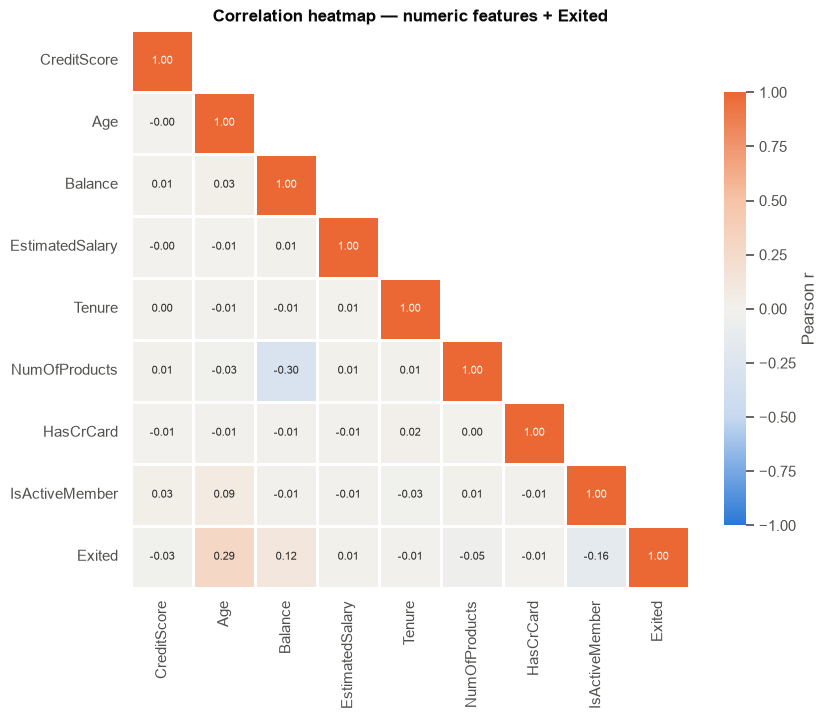

In [16]:
eda.plot_correlation_heatmap(df);

**Observation:** features are almost uncorrelated with each other; the only notable pair is Balance–NumOfProducts
(r = −0.30). Strongest linear links to `Exited` are Age (+0.29), IsActiveMember (−0.16) and Balance (+0.12). NumOfProducts
shows only −0.05 because its effect is U-shaped — Pearson r misses it.

### Churn-rate heatmap: Geography × Gender

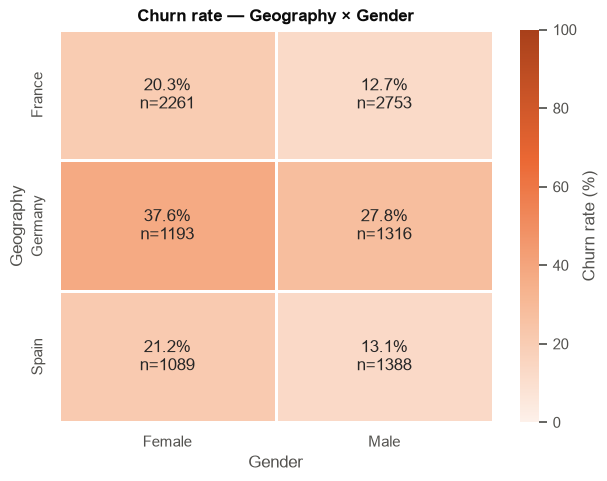

In [17]:
eda.plot_churn_heatmap(df, "Geography", "Gender");

**Observation:** the two effects stack: German women churn at **37.6%**, French men at only 12.7%. Women churn more
than men in every country (by 8–10 points).

### Churn-rate heatmap: NumOfProducts × IsActiveMember

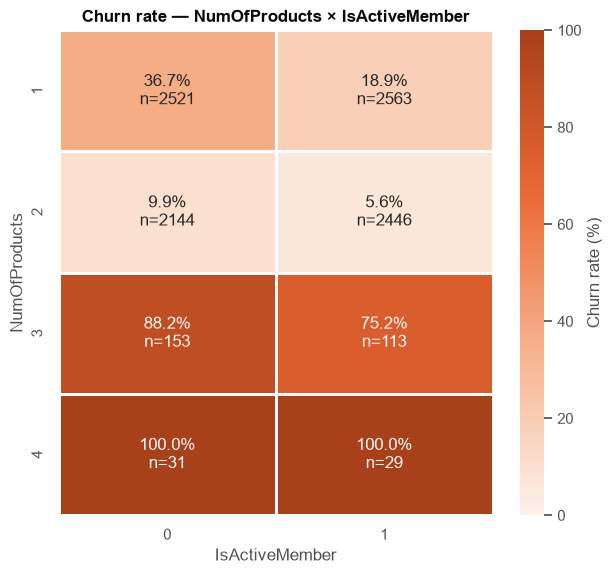

In [18]:
eda.plot_churn_heatmap(df, "NumOfProducts", "IsActiveMember");

**Observation:** inactivity roughly doubles churn among 1-product customers (36.7% vs 18.9%). With 2 products churn
stays low even when inactive (9.9%), while 3–4 products churn heavily regardless of activity (75–100%, small n).

### Pairplot of continuous features (2,000-row sample)

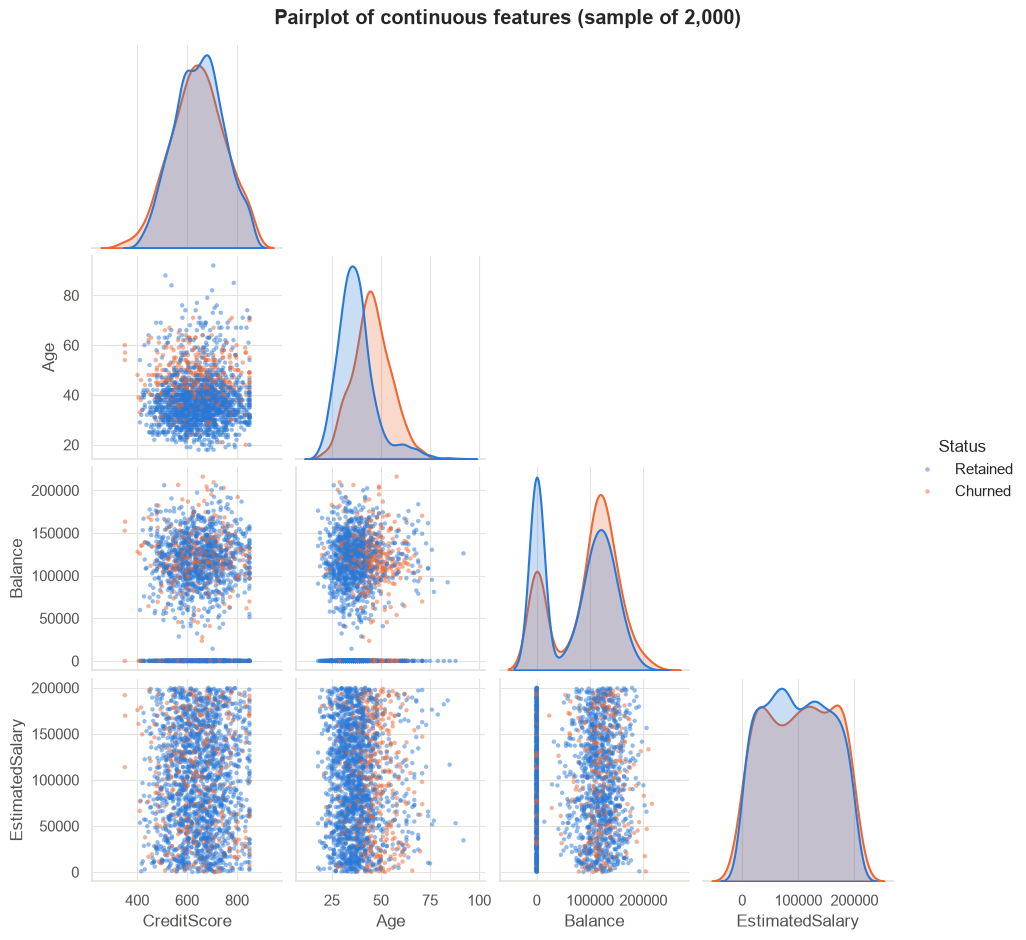

In [19]:
eda.plot_pairplot(df);

**Observation:** no pair of continuous features separates churners cleanly; the only visible structure is churners
shifting to the older end of every Age panel and the Balance zero/non-zero split. Signal is mostly univariate + interactions,
not linear combinations.

### Multicollinearity (VIF)

In [20]:
eda.vif_table(df)

,feature,r_squared,vif,concern
0,NumOfProducts,0.094,1.103,low
1,Balance,0.094,1.103,low
2,IsActiveMember,0.009,1.009,low
3,Age,0.009,1.009,low
4,Tenure,0.002,1.002,low
5,HasCrCard,0.001,1.001,low
6,CreditScore,0.001,1.001,low
7,EstimatedSalary,0.001,1.001,low


**Observation:** every VIF is ≈ 1.0 (max 1.10 for Balance and NumOfProducts) — no multicollinearity, so no feature
needs to be dropped for linear models. Saved to `reports/vif.csv`.

## Part E — Summary
The key findings and the feature-engineering hypotheses derived from them are written up in
[`reports/eda_summary.md`](../reports/eda_summary.md).

In [21]:
from src.config import FIGURES_DIR
figures = sorted(p.name for p in FIGURES_DIR.glob("*.png"))
print(f"{len(figures)} figures saved:")
print("\n".join(figures))

14 figures saved:
categorical_counts.png
churn_heatmap_geography_x_gender.png
churn_heatmap_numofproducts_x_isactivemember.png
churn_rate_balance_zero.png
churn_rate_by_age_band.png
churn_rate_by_category.png
continuous_vs_churn.png
correlation_heatmap.png
distribution_age.png
distribution_balance.png
distribution_creditscore.png
distribution_estimatedsalary.png
pairplot_continuous.png
target_distribution.png
